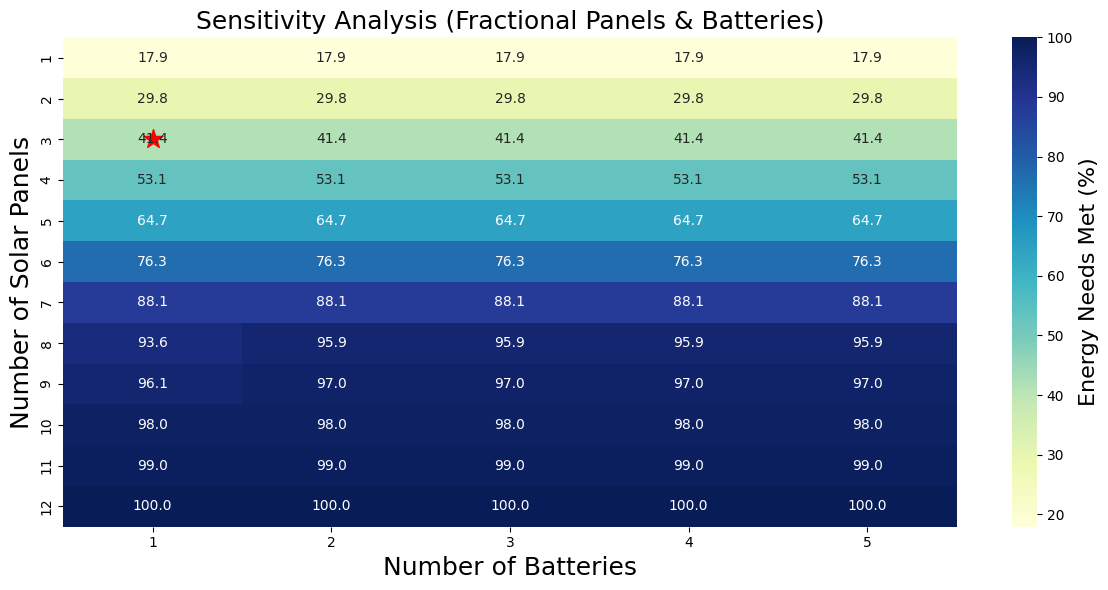

In [ ]:
# Load in necessary imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Load data from smart home
df = pd.read_excel('SmartHomeSeptemberSA.xlsx', parse_dates=['Date & Time']).head(10081)

# Calculate the state of charge
def calculate_soc(row, prev_soc, num_panels=1, num_batteries=1, battery_capacity=13.5, roundtrip_eff=0.93):
  ''' This is a function that calculates the state of charge (SOC) of the battery and solar panel system
  Inputs: Row - the row in the SmartHome data set that includes time, generation, and consumption
          Prev_soc - the previous time value state of charge
          num_panels - the number of solar panels used
          num_batteries - the number of batteries used
          roundtrip_eff - the efficiency of the battery charge/discharge
  Outputs: SOC - the current state of charge of the battery '''

    dt = 1/60  # 1 minute time step
    eta = np.sqrt(roundtrip_eff) # Efficiency  value
    hour = row['Date & Time'].hour + row['Date & Time'].minute/60 # Extract time data
    is_peak = 3.5 <= hour < 21  # peak hours 3:30 am to 9 pm

    solar_kWh = row['gen [kW]'] * num_panels * dt # Total generation
    demand_kWh = row['use [kW]'] * dt # Total demand

    if is_peak:
        # During peak hours: solar powers house first, excess charges battery
        solar_to_house = min(solar_kWh, demand_kWh)
        excess_solar = solar_kWh - solar_to_house
        remaining_demand = demand_kWh - solar_to_house

        # Battery only discharges if solar can't meet demand
        if remaining_demand > 0:
            battery_discharge = min(prev_soc * eta, remaining_demand / eta)
            prev_soc -= battery_discharge
            remaining_demand -= battery_discharge * eta
        else:
            # Charge battery with excess solar
            charge_amount = min(excess_solar * eta, (num_batteries * battery_capacity) - prev_soc)
            prev_soc += charge_amount
    else:
        # Off-peak hours: solar charges battery, battery powers house
        # First charge battery with solar
        charge_amount = min(solar_kWh * eta, (num_batteries * battery_capacity) - prev_soc)
        prev_soc += charge_amount

        # Then power house from battery
        battery_discharge = min(prev_soc * eta, demand_kWh / eta)
        prev_soc -= battery_discharge

    # Ensure SOC stays within bounds
    return max(0, min(num_batteries * battery_capacity, prev_soc))

# Calculate energy met
def compute_energy_met(df, num_panels, num_batteries):
  ''' This function uses the state of charge function to calculate the percentage of energy demands met for a given number of panels and batteries
  inputs - df - consumption and generation data
          num_panels - number of solar panels used
          num_batteires - number of batteries used
  Outputs - Energy_met - the percentage of energy demand met '''

    soc = 6.75  # Initial state of charge
    unmet = 0 # All demand is met at time 0
    total_demand = df['use [kW]'].sum() * (1/60)  # Convert kW-minutes to kWh

    for _, row in df.iterrows():
        hour = row['Date & Time'].hour + row['Date & Time'].minute/60
        is_peak = 3.5 <= hour < 21
        dt = 1/60
        solar_kWh = row['gen [kW]'] * num_panels * dt
        demand_kWh = row['use [kW]'] * dt

        # Calculate how much demand is met before updating SOC
        if is_peak:
            # Solar meets demand first
            met_by_solar = min(solar_kWh, demand_kWh)
            remaining_demand = demand_kWh - met_by_solar
            # Then battery meets remaining demand
            available_from_battery = min(soc * np.sqrt(0.93), remaining_demand / np.sqrt(0.93))
            unmet += max(0, remaining_demand - available_from_battery * np.sqrt(0.93))
        else:
            # All demand must be met by battery
            available_from_battery = min(soc * np.sqrt(0.93), demand_kWh / np.sqrt(0.93))
            unmet += max(0, demand_kWh - available_from_battery * np.sqrt(0.93))

        # Update SOC for next iteration
        soc = calculate_soc(row, soc, num_panels, num_batteries)

    return 100 * (total_demand - unmet) / total_demand


# Generate heatmap data
batteries = np.linspace(1,5, 5) # 5 battery system max
panels = np.linspace(1,12, 12) # 12 Solar Panels max
results = []

# Calculate energy needs met for each situation
for num_batteries in batteries:
    for num_panels in panels:
        met_pct = compute_energy_met(df, num_panels, num_batteries)
        results.append({
            'Batteries': round(num_batteries, 2),
            'Solar Panels': round(num_panels, 2),
            'Energy Met (%)': met_pct
        })

heatmap_df = pd.DataFrame(results)

# Create pivot table with numeric values
pivot_df = heatmap_df.pivot(
    index="Solar Panels",
    columns="Batteries",
    values="Energy Met (%)"
)

# Sort the index and columns numerically
pivot_df = pivot_df.sort_index(axis=0).sort_index(axis=1)

# Convert to strings only for display labels
pivot_df.index = pivot_df.index.astype(int).astype(str)
pivot_df.columns = pivot_df.columns.astype(int).astype(str)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Energy Needs Met (%)'})

# Adjust colorbar label font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(16)

ax.scatter(x=0.5, y=2.5, marker='*', s=200, color='red')

plt.title('Sensitivity Analysis (Fractional Panels & Batteries)', fontsize=18)
plt.xlabel('Number of Batteries', fontsize=18)
plt.ylabel('Number of Solar Panels', fontsize=18)
plt.tight_layout()
plt.show()